In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (SINKRON DENGAN POPULASI)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Parameter Kapasitas & Reputasi ---
kapasitas_pengunjung_harian = 2752
lama_tinggal = 3

# --- B. Data Historis Wisatawan ---
dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

# Laju Historis & BAU
r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- C. Parameter Finansial (PNBP) ---
target_2026_val = 30_000_000_000  # Rp 30 Miliar
avg_tiket_dom = ((5 * 54000) + (2 * 79000)) / 7
avg_tiket_man = 255000  # Sesuai Appendix A
persentase_retribusi = 0.85

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP INTEGRATION)
# ==========================================
dates = []
curr_dom_bau = dom_2023 / 365
curr_man_bau = man_2023 / 365
reputasi_bau = 1.0

data_revenue_daily = []
curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # 1. Tentukan Laju Pertumbuhan Dasar
    if year == 2023:
        g_dom, g_man = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom, g_man = r_dom_24_25, r_man_24_25
    else:
        g_dom, g_man = daily_growth_bau, daily_growth_bau

    # 2. Efek Kepadatan (Crowding Effect) menekan Reputasi
    pop_bau_today = curr_dom_bau + curr_man_bau
    if pop_bau_today > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_bau_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    # 3. Update Populasi (Arus Masuk - Arus Keluar)
    outflow_bau_dom = curr_dom_bau / lama_tinggal
    outflow_bau_man = curr_man_bau / lama_tinggal

    inflow_bau_dom = (outflow_bau_dom + curr_dom_bau * g_dom) * reputasi_bau
    inflow_bau_man = (outflow_bau_man + curr_man_bau * g_man) * reputasi_bau

    curr_dom_bau += (inflow_bau_dom - outflow_bau_dom)
    curr_man_bau += (inflow_bau_man - outflow_bau_man)

    # 4. TRANSLASI KE FINANSIAL (Daily Revenue)
    # Terapkan penyesuaian tarif historis TNBTS
    if year == 2023:
        # Tarif Lama (29k weekday, 34k weekend)
        tiket_dom_berlaku = ((5 * 29000) + (2 * 34000)) / 7
        tiket_man_berlaku = 220000
    else:
        # Tarif Baru 2024 ke atas (sudah kamu definisikan di parameter atas)
        tiket_dom_berlaku = avg_tiket_dom
        tiket_man_berlaku = avg_tiket_man

    # Pendapatan murni bergantung pada jumlah orang
    daily_revenue = ((curr_dom_bau * tiket_dom_berlaku) + (curr_man_bau * tiket_man_berlaku)) * persentase_retribusi

    # Simpan sebagai Run-Rate Tahunan (agar skalanya langsung Miliar Rupiah di grafik)
    annualized_revenue = daily_revenue * 365
    data_revenue_daily.append(annualized_revenue)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates), "Revenue_Raw": data_revenue_daily})

# Smoothing agar kurva mulus (menyetrika efek lompatan tahun kalender)
df["Revenue_Smooth"] = df["Revenue_Raw"].rolling(window=180, min_periods=1, center=True).mean()

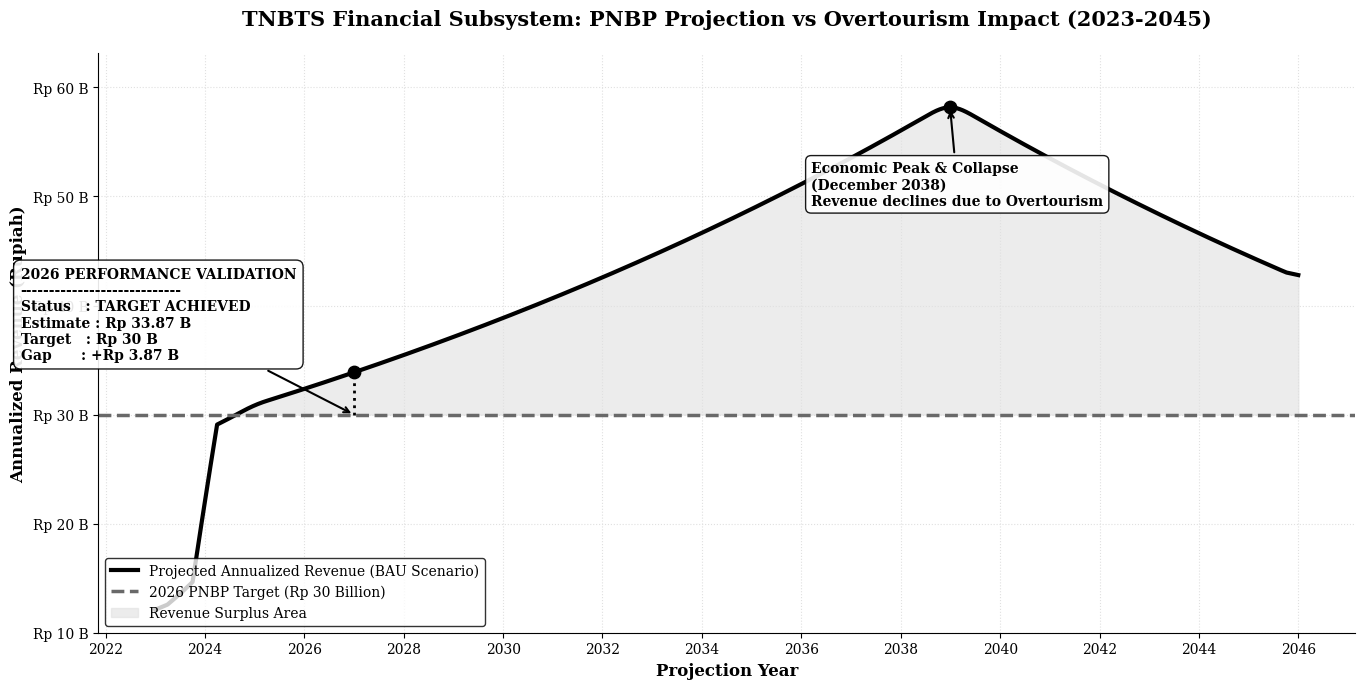

In [ ]:
# ==========================================
# 4. VISUALISASI GRAFIK (MONOKROM AKADEMIS)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Kurva Pendapatan
ax1.plot(df["Date"], df["Revenue_Smooth"], color="black", linestyle="-", linewidth=3, label="Projected Annualized Revenue (BAU Scenario)")

# Garis Target PNBP 2026
ax1.axhline(y=target_2026_val, color="dimgray", linestyle="--", linewidth=2.5, label="2026 PNBP Target (Rp 30 Billion)")

# Arsiran Area Surplus (> 30 Miliar)
ax1.fill_between(df["Date"], df["Revenue_Smooth"], target_2026_val,
                 where=(df["Revenue_Smooth"] >= target_2026_val),
                 color="#e0e0e0", alpha=0.6, label="Revenue Surplus Area")

# ------------------------------------------
# ANOTASI: VALIDASI TARGET 2026
# ------------------------------------------
date_2026 = pd.Timestamp('2026-12-31')
# Ambil nilai terdekat dari data smooth
val_2026 = df.loc[df['Date'] >= date_2026, 'Revenue_Smooth'].values[0]
gap = val_2026 - target_2026_val
is_achieved = gap >= 0
status_title = "TARGET ACHIEVED" if is_achieved else "TARGET MISSED (DEFICIT)"

ax1.vlines(x=date_2026, ymin=target_2026_val, ymax=val_2026, color='black', linestyle=':', linewidth=2)
ax1.scatter(date_2026, val_2026, color='black', s=80, zorder=10)

info_text = (f"2026 PERFORMANCE VALIDATION\n"
             f"{'-'*28}\n"
             f"Status   : {status_title}\n"
             f"Estimate : Rp {val_2026/1e9:.2f} B\n"
             f"Target   : Rp {target_2026_val/1e9:.0f} B\n"
             f"Gap      : {'+' if is_achieved else '-'}Rp {abs(gap)/1e9:.2f} B")

ax1.annotate(info_text, xy=(date_2026, target_2026_val), xytext=(-240, 40), textcoords='offset points',
             arrowprops=dict(arrowstyle="->", color='black', linewidth=1.5),
             fontsize=10, fontweight='bold', color='black',
             bbox=dict(boxstyle="round,pad=0.5", fc='white', ec='black', alpha=0.9))

# ------------------------------------------
# ANOTASI: PUNCAK OVERTOURISM & KEMEROSOTAN EKONOMI
# ------------------------------------------
peak_row = df.loc[df["Revenue_Smooth"].idxmax()]
peak_date = peak_row["Date"]
peak_val = peak_row["Revenue_Smooth"]

ax1.scatter(peak_date, peak_val, color='black', s=80, zorder=10)
ax1.annotate(f"Economic Peak & Collapse\n({peak_date.strftime('%B %Y')})\nRevenue declines due to Overtourism",
             xy=(peak_date, peak_val), xytext=(-100, -70), textcoords='offset points',
             fontsize=10, weight='bold', color='black',
             arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
             bbox=dict(boxstyle="round,pad=0.4", fc='white', ec='black', alpha=0.9))

# ------------------------------------------
# FORMATTING SUMBU & FRAME
# ------------------------------------------
def annual_billions(x, pos):
    return 'Rp %1.0f B' % (x*1e-9)

ax1.yaxis.set_major_formatter(ticker.FuncFormatter(annual_billions))
ax1.set_title('TNBTS Financial Subsystem: PNBP Projection vs Overtourism Impact (2023-2045)', fontsize=15, fontweight='bold', pad=20)
ax1.set_ylabel('Annualized Revenue (Rupiah)', fontsize=12, fontweight="bold")
ax1.set_xlabel('Projection Year', fontsize=12, fontweight="bold")

ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.set_ylim(bottom=10_000_000_000, top=max(df["Revenue_Smooth"]) + 5_000_000_000)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. EXPORT DATA TAHUNAN
# ==========================================
df['Year'] = df['Date'].dt.year
df_annual = df.groupby("Year").agg(Estimated_Annual_Revenue=("Revenue_Smooth", "mean")).reset_index()

print("\n" + "=" * 80)
print("   TABEL PROYEKSI PENDAPATAN PNBP TNBTS (SKENARIO BAU TERINTEGRASI)")
print("=" * 80)
print(f"{'Tahun':<6} | {'Proyeksi Pendapatan Tahunan (Rp)':<35} | {'Status Target 2026'}")
print("-" * 80)

for _, row in df_annual[df_annual["Year"] >= 2024].iterrows():
    year = int(row["Year"])
    rev = row["Estimated_Annual_Revenue"]
    status = "SURPLUS" if rev >= target_2026_val else "DEFICIT"
    print(f"{year:<6} | Rp {rev:>30,.0f} | {status}")
print("=" * 80)


   TABEL PROYEKSI PENDAPATAN PNBP TNBTS (SKENARIO BAU TERINTEGRASI)
Tahun  | Proyeksi Pendapatan Tahunan (Rp)    | Status Target 2026
--------------------------------------------------------------------------------
2024   | Rp                 28,878,300,621 | DEFICIT
2025   | Rp                 31,622,319,120 | SURPLUS
2026   | Rp                 33,108,259,555 | SURPLUS
2027   | Rp                 34,657,726,102 | SURPLUS
2028   | Rp                 36,281,998,199 | SURPLUS
2029   | Rp                 37,982,357,247 | SURPLUS
2030   | Rp                 39,759,931,567 | SURPLUS
2031   | Rp                 41,620,696,364 | SURPLUS
2032   | Rp                 43,571,295,649 | SURPLUS
2033   | Rp                 45,613,268,266 | SURPLUS
2034   | Rp                 47,747,969,221 | SURPLUS
2035   | Rp                 49,982,574,180 | SURPLUS
2036   | Rp                 52,325,061,980 | SURPLUS
2037   | Rp                 54,777,280,629 | SURPLUS
2038   | Rp                 57,275,331,482

In [ ]:
# ==========================================
# 6. EVALUASI MAPE: SUBSISTEM EKONOMI
# ==========================================

# 1. Perbaikan Logika Agregasi
# Kembalikan 'Revenue_Raw' (yang sebelumnya dikali 365) menjadi pendapatan harian riil murni
df['Pendapatan_Harian_Riil'] = df['Revenue_Raw'] / 365

# 2. Agregasi Pendapatan Riil menjadi Total Tahunan
df['Tahun'] = df['Date'].dt.year
df_ekonomi_tahunan = df.groupby('Tahun').agg(
    Total_PNBP_Simulasi=('Pendapatan_Harian_Riil', 'sum')
).reset_index()

# Konversi hasil simulasi ke satuan Miliar Rupiah agar selaras dengan data aktual
df_ekonomi_tahunan['PNBP_Miliar_Simulasi'] = df_ekonomi_tahunan['Total_PNBP_Simulasi'] / 1_000_000_000

# 3. Masukkan Data Aktual (Riil) PNBP TNBTS (dalam Miliar Rupiah)
data_aktual_pnbp = {
    2023: 14.70,
    2024: 21.15
}
df_aktual_ekonomi = pd.DataFrame(list(data_aktual_pnbp.items()), columns=['Tahun', 'Aktual_PNBP_Miliar'])

# 4. Gabungkan dan Hitung MAPE
df_eval_eko = pd.merge(df_aktual_ekonomi, df_ekonomi_tahunan, on='Tahun', how='inner')
df_eval_eko['APE'] = np.abs((df_eval_eko['Aktual_PNBP_Miliar'] - df_eval_eko['PNBP_Miliar_Simulasi']) / df_eval_eko['Aktual_PNBP_Miliar']) * 100
mape_ekonomi = df_eval_eko['APE'].mean()

# 5. Tampilkan Hasil Evaluasi Ekonomi
print("\n" + "="*75)
print("       EVALUASI MAPE: SUBSISTEM EKONOMI (PNBP TNBTS)")
print("="*75)
print(df_eval_eko[['Tahun', 'Aktual_PNBP_Miliar', 'PNBP_Miliar_Simulasi', 'APE']].rename(
    columns={'Aktual_PNBP_Miliar': 'Aktual (Miliar Rp)', 'PNBP_Miliar_Simulasi': 'Simulasi (Miliar Rp)', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 75)
print(f"NILAI MAPE SUBSISTEM EKONOMI : {mape_ekonomi:.2f}%")

if mape_ekonomi < 10:
    kategori_eko = "Sangat Akurat (Highly Accurate)"
elif mape_ekonomi < 20:
    kategori_eko = "Baik (Good)"
elif mape_ekonomi < 50:
    kategori_eko = "Cukup (Reasonable)"
else:
    kategori_eko = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI             : {kategori_eko}")
print("=" * 75)


       EVALUASI MAPE: SUBSISTEM EKONOMI (PNBP TNBTS)
 Tahun  Aktual (Miliar Rp)  Simulasi (Miliar Rp)  Error (%)
  2023               14.70                 13.61       7.38
  2024               21.15                 29.77      40.76
---------------------------------------------------------------------------
NILAI MAPE SUBSISTEM EKONOMI : 24.07%
KATEGORI AKURASI             : Cukup (Reasonable)


In [ ]:
import pandas as pd
import numpy as np
from datetime import date, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. PARAMETERS (EKONOMI + EKOLOGI)
# ==========================================
start_date = date(2023,1,1)
end_date = date(2045,12,31)
days = (end_date - start_date).days + 1
target_threshold = 30_000_000_000  # Rp 30B

# --- Ekologi (Kapasitas Fisik) ---
kapasitas_pengunjung_harian = 2752
lama_tinggal = 3

# --- Historis Wisatawan ---
dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12/9)
man_2025_est = 13300 * (12/9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1
daily_growth_int = (1 + 0.035) ** (1 / 365) - 1 # Post-intervention growth

# --- Ekonomi (Harga & Elastisitas) ---
elasticity = -0.504
persentase_retribusi = 0.85

price_dom_old = ((5 * 54000) + (2 * 79000)) / 7
price_man_old = 255000

price_dom_new = ((5 * 58320) + (2 * 90850)) / 7
price_man_new = 318750

shock_dom = ((price_dom_new - price_dom_old) / price_dom_old) * elasticity
shock_man = ((price_man_new - price_man_old) / price_man_old) * elasticity

In [ ]:
# ==========================================
# 2. SIMULATION ENGINE (CAUSAL LOOP)
# ==========================================
dates = []
rev_bau_daily = []
rev_int_daily = []

curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
curr_dom_int, curr_man_int = dom_2023 / 365, man_2023 / 365

reputasi_bau = 1.0
reputasi_int = 1.0
curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- 1. GROWTH RATES ---
    if year == 2023:
        g_dom_bau, g_man_bau = r_dom_23_24, r_man_23_24
        g_dom_int, g_man_int = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom_bau, g_man_bau = r_dom_24_25, r_man_24_25
        g_dom_int, g_man_int = r_dom_24_25, r_man_24_25
    else:
        g_dom_bau, g_man_bau = daily_growth_bau, daily_growth_bau
        if year == 2026 and curr_date == date(2026, 1, 1):
            curr_dom_int *= (1 + shock_dom)
            curr_man_int *= (1 + shock_man)
        elif year >= 2026:
            g_dom_int, g_man_int = daily_growth_int, daily_growth_int
        else:
            g_dom_int, g_man_int = daily_growth_bau, daily_growth_bau

    # --- 2. CROWDING EFFECT (Reputasi Jatuh Jika Sesak) ---
    pop_bau_today = curr_dom_bau + curr_man_bau
    if pop_bau_today > kapasitas_pengunjung_harian:
        reputasi_bau -= (pop_bau_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    pop_int_today = curr_dom_int + curr_man_int
    if pop_int_today > kapasitas_pengunjung_harian:
        reputasi_int -= (pop_int_today / kapasitas_pengunjung_harian - 1.0) * 0.0004
    reputasi_int = max(0.80, reputasi_int)

    # --- 3. POPULATION UPDATE ---
    # BAU
    out_bau_dom, out_bau_man = curr_dom_bau / lama_tinggal, curr_man_bau / lama_tinggal
    in_bau_dom = (out_bau_dom + curr_dom_bau * g_dom_bau) * reputasi_bau
    in_bau_man = (out_bau_man + curr_man_bau * g_man_bau) * reputasi_bau
    curr_dom_bau += (in_bau_dom - out_bau_dom)
    curr_man_bau += (in_bau_man - out_bau_man)

    # INTERVENTION
    out_int_dom, out_int_man = curr_dom_int / lama_tinggal, curr_man_int / lama_tinggal
    if year >= 2026:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_int) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_int) * reputasi_int
    else:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_bau) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_bau) * reputasi_int

    curr_dom_int += (in_int_dom - out_int_dom)
    curr_man_int += (in_int_man - out_int_man)

    # --- 4. REVENUE CALCULATION ---
    daily_rev_bau = ((curr_dom_bau * price_dom_old) + (curr_man_bau * price_man_old)) * persentase_retribusi

    price_dom_curr = price_dom_new if year >= 2026 else price_dom_old
    price_man_curr = price_man_new if year >= 2026 else price_man_old
    daily_rev_int = ((curr_dom_int * price_dom_curr) + (curr_man_int * price_man_curr)) * persentase_retribusi

    rev_bau_daily.append(daily_rev_bau * 365) # Annualized
    rev_int_daily.append(daily_rev_int * 365) # Annualized

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates), "BAU_Raw": rev_bau_daily, "INT_Raw": rev_int_daily})
df["BAU_Smooth"] = df["BAU_Raw"].rolling(window=180, min_periods=1, center=True).mean()
df["INT_Smooth"] = df["INT_Raw"].rolling(window=180, min_periods=1, center=True).mean()

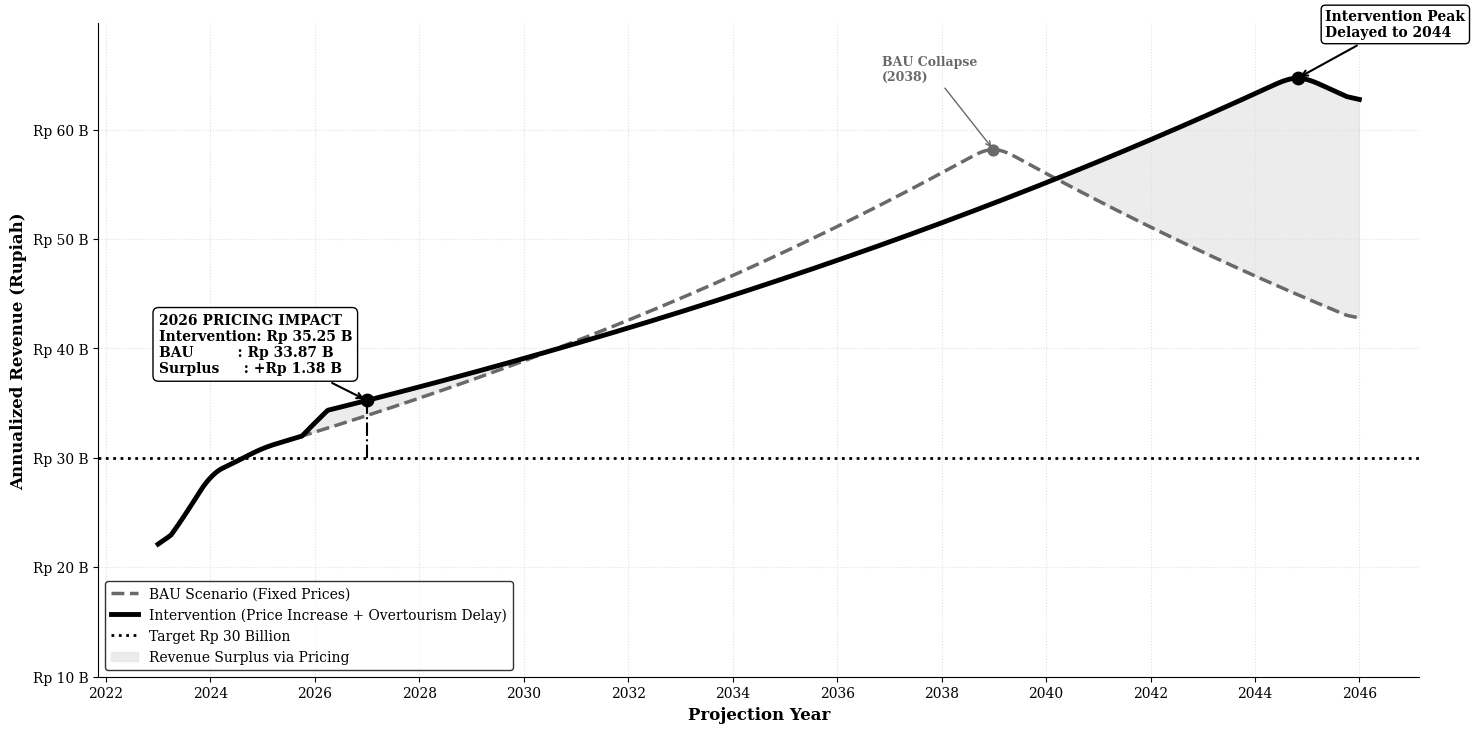

In [ ]:
# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax = plt.subplots(figsize=(15, 7.5))

# Plot lines
ax.plot(df['Date'], df['BAU_Smooth'], color='dimgray', linestyle='--', linewidth=2.5, label='BAU Scenario (Fixed Prices)')
ax.plot(df['Date'], df['INT_Smooth'], color='black', linewidth=3.5, label='Intervention (Price Increase + Overtourism Delay)')

# Target line
ax.axhline(y=target_threshold, color='black', linestyle=':', linewidth=2, label='Target Rp 30 Billion')

# Surplus Area (where Int > BAU)
ax.fill_between(df['Date'], df['INT_Smooth'], df['BAU_Smooth'], where=(df['INT_Smooth'] > df['BAU_Smooth']),
                color='#e0e0e0', alpha=0.6, label='Revenue Surplus via Pricing')

# ------------------------------------------
# ANOTASI: 2026 STATUS
# ------------------------------------------
date_2026 = pd.Timestamp('2026-12-31')
val_bau_2026 = df.loc[df['Date'] >= date_2026, 'BAU_Smooth'].values[0]
val_int_2026 = df.loc[df['Date'] >= date_2026, 'INT_Smooth'].values[0]

ax.vlines(x=date_2026, ymin=target_threshold, ymax=val_int_2026, color='black', linestyle='-.', linewidth=1.5)
ax.scatter(date_2026, val_int_2026, color='black', s=80, zorder=10)

info_text = (f"2026 PRICING IMPACT\n"
             f"Intervention: Rp {val_int_2026/1e9:.2f} B\n"
             f"BAU         : Rp {val_bau_2026/1e9:.2f} B\n"
             f"Surplus     : +Rp {(val_int_2026-val_bau_2026)/1e9:.2f} B")

ax.annotate(info_text, xy=(date_2026, val_int_2026), xytext=(-150, 20),
            textcoords='offset points', arrowprops=dict(arrowstyle="->", color='black', linewidth=1.5),
            fontsize=10, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.4", fc='white', ec='black'))

# ------------------------------------------
# ANOTASI: PEAK & COLLAPSE (BAU vs INT)
# ------------------------------------------
peak_bau = df.loc[df["BAU_Smooth"].idxmax()]
ax.scatter(peak_bau["Date"], peak_bau["BAU_Smooth"], color='dimgray', s=60, zorder=10)
ax.annotate(f"BAU Collapse\n({peak_bau['Date'].strftime('%Y')})",
            xy=(peak_bau["Date"], peak_bau["BAU_Smooth"]), xytext=(-80, 50), textcoords='offset points',
            fontsize=9, weight='bold', color='dimgray', arrowprops=dict(arrowstyle="->", color='dimgray'))

peak_int = df.loc[df["INT_Smooth"].idxmax()]
ax.scatter(peak_int["Date"], peak_int["INT_Smooth"], color='black', s=80, zorder=10)
ax.annotate(f"Intervention Peak\nDelayed to {peak_int['Date'].strftime('%Y')}",
            xy=(peak_int["Date"], peak_int["INT_Smooth"]), xytext=(20, 30), textcoords='offset points',
            fontsize=10, weight='bold', color='black', arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='black'))

# Axes formatting
def annual_billions(x,pos):
    return 'Rp %1.0f B' % (x*1e-9)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(annual_billions))
ax.set_ylabel('Annualized Revenue (Rupiah)',fontsize=12, fontweight='bold')
ax.set_xlabel('Projection Year',fontsize=12, fontweight='bold')

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(bottom=10_000_000_000, top=max(df["INT_Smooth"]) + 5_000_000_000)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc='lower left', fontsize=10)

plt.tight_layout()
plt.show()